[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tuo-utente/tuo-repo/blob/main/lezione1.ipynb)

# Multi-class classification

All classification algorithms seen so far are binary classification algorithms (2 classes).

We can extend any binary classification algorithm to the multi-class problem using 2 approaches:

1. One vs. Rest (OvR) or One vs. All (OvA)
2. One vs. One (OvO)

## Classification One vs. Rest

- The dataset is divided into many sub-datasets (one for each class)
- Train a binary classifier for each sub-dataset
- Foretells the class of an example based on the most "sure" model

For example, let's consider a 3 class Calsification problem (__PLC_0_). Let's build 3 binary classification problems:

1. $red$ vs $[blue, green]$
2. $blue$ vs $[red, green]$
3. __PLC_5_ vs $[red, blue]$

<img src="images/OvR2.jpeg" width="750">

### OvR, advantages and criticalities

__Pros__ :

- Good scalability with class number (3 classes --> 3 classifiers; 10 classes --> 10 classifiers)

__Cons__ :

- Generally leads to unbalanced classes (especially when you have a large number of classes)

### ...in Python

Class labels: [0 1 2]


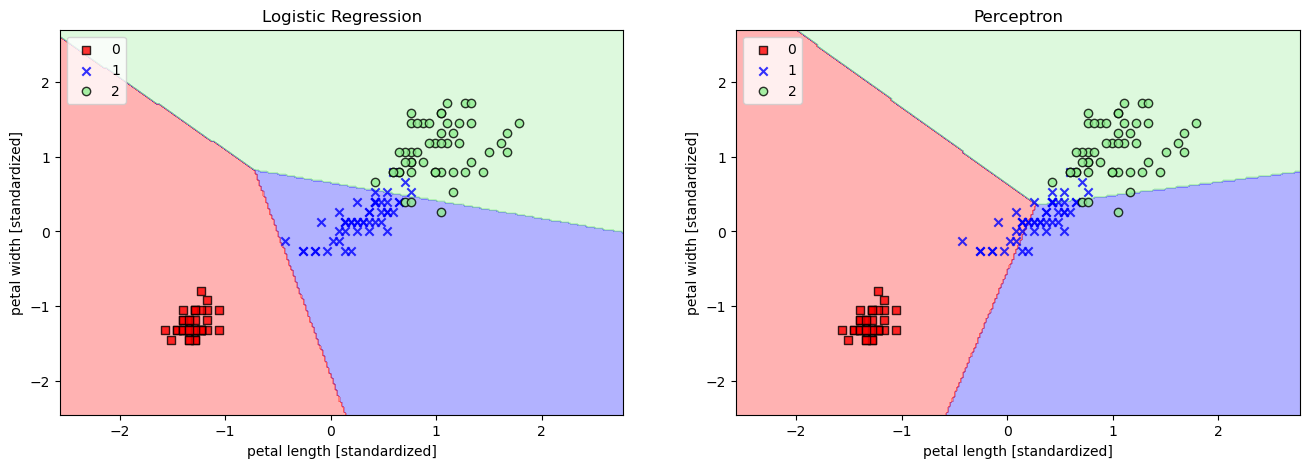

In [1]:
import numpy as np
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn import datasets
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')
        

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

print('Class labels:', np.unique(y))

lr = LogisticRegression(random_state=123, solver='lbfgs')
ppn = Perceptron(eta0=0.01, random_state=123)

ovr_lr = OneVsRestClassifier(lr).fit(X, y)
ovr_ppn = OneVsRestClassifier(ppn).fit(X, y)

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression')

plt.subplot(1,2,2)
plot_decision_regions(X, y, classifier=ovr_ppn)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron')

plt.show()

## Classification One vs. One

- As with OvR, it treats multiclass classification as many binary classification problems
- Each class is compared with every possible other

For example, consider a 4 class ($red, blue, green, yellow$) classification problem. OvO transforms the problem into $6$ binary classification problems:

1. $red$ vs. $blue$
2. $red$ vs. $green$
3. $red$ vs. $yellow$
4. $blue$ vs. $green$
5. $blue$ vs. $yellow$
6. $green$ vs. $yellow$

In general, if we have $K$ classes, OvO will produce $P = \frac{K(K-1)}{2}$ binary classification problems:

- Each classifier predicts a label associated with each example of the dataset. Each point is then ranked by a majority vote among the $P$ binary classifiers.

<img src="images/OvO2.jpeg" width="750">

### OvO, advantages and criticalities

__Pros__ :

- Does not generate imbalance of classes if the starting dataset is balanced

__Cons__ :

- Scales worse with the number of classes (3 classes --> 3 classifiers; 10 classes --> 45 classifiers)

### ...in Python

Class labels: [0 1 2]


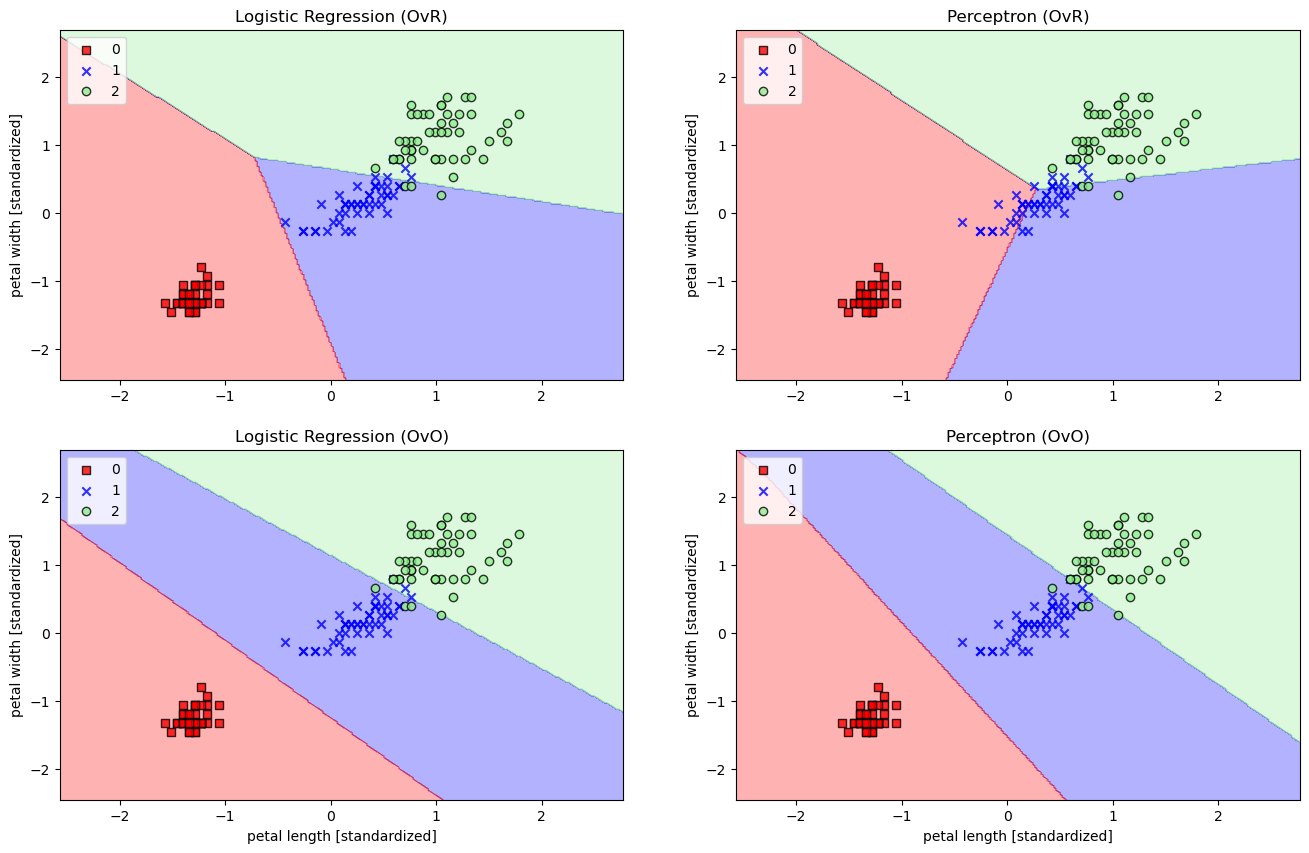

In [2]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

print('Class labels:', np.unique(y))

lr = LogisticRegression(random_state=123, solver='lbfgs')
ppn = Perceptron(eta0=0.01, random_state=123)

ovo_lr = OneVsOneClassifier(lr).fit(X, y)
ovo_ppn = OneVsOneClassifier(ppn).fit(X, y)

plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvR)')

plt.subplot(2,2,2)
plot_decision_regions(X, y, classifier=ovr_ppn)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron (OvR)')

plt.subplot(2,2,3)
plot_decision_regions(X, y, classifier=ovo_lr)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvO)')

plt.subplot(2,2,4)
plot_decision_regions(X, y, classifier=ovo_ppn)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron (OvO)')
plt.show()

## Natively Multiclass Classifiaction Models

There are some models that can be reformulated to natively handle multiple classes, without the need to resort to heuristics like OvR and OvO. Among those we have seen, one of these is the Logistic Regression.

The LR can be generalized to the multi-class case and takes the name of __Multinomial Logistic Regression__

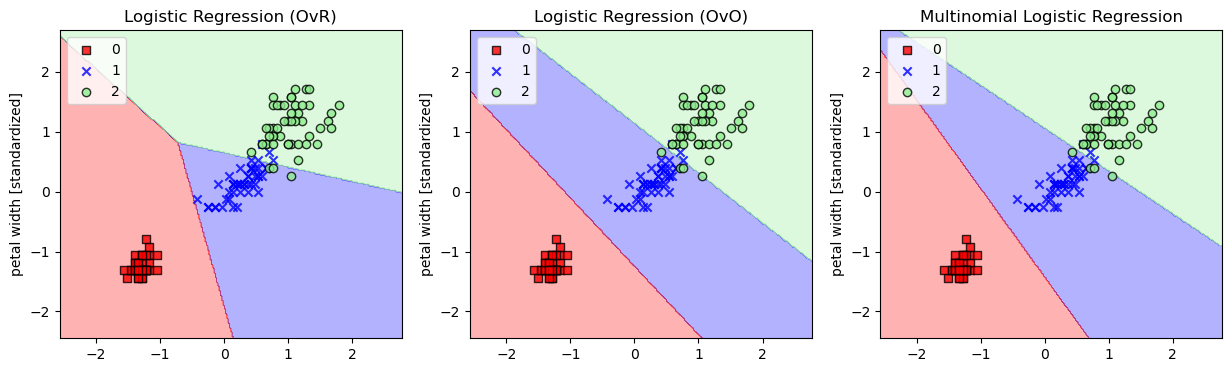

In [3]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

mlr = LogisticRegression(random_state=123, multi_class='multinomial')
mlr.fit(X, y)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvR)')

plt.subplot(1,3,2)
plot_decision_regions(X, y, classifier=ovo_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvO)')

plt.subplot(1,3,3)
plot_decision_regions(X, y, classifier=mlr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Multinomial Logistic Regression')
plt.show()